# Issues
- For vertical levels, sigma-level approximation is used instead of the true hybrid level coordinate system. Pressure levels defined by sigma values are calculated as$$p_{\text{level}} = \sigma_{\text{level}} * p_{\text{surface}}$$ and these $\sigma_{\text{level}}$ are retrieved from [this FAQ page](https://rapidrefresh.noaa.gov/faq/HRRR.faq.html). However, I suspect that this source is outdated as StormCast documentation refers to HRRR's vertical coordinate system as **hybrid** levels and section 2.1 of [this documentation](https://opensky.ucar.edu/islandora/object/technotes%3A576) of Advanced Research WRF model v4 describes a hybrid level system that I suspect HRRR v4 (the latest version) also uses. Anyway I couldn't find a source for the parameters corresponding to each level in the hybrid system so the sigma levels are used as a first attempt approximation.

- HRRR uses Lambert Conformal Grid. However my conversion from ERA5's lat/lon grid to HRRR-format input just bilinearly interpolates the ERA5 grid (something like a spherical coordinate grid) to the required resolution. Again, suitable for a first approximation.

- Composite reflectivity, `refc`, is one of HRRR's 99 variables but does not exist in ERA5. Set to zero everywhere initial conditions for now.

- Some functions are designed to handle multiple initialisation times while others are designed to only handle one (ie assumes that `len(times)==1`). Just stick to one initialisation time for now – I don't quite get the purpose of multiple initialisation times yet.

In [1]:
# ── 0. Install & imports ──────────────────────────────────────────────────────

!pip install -q earth2studio[stormcast]

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import earth2studio.run as run

import utils as ut
import importlib
importlib.reload(ut)

from earth2studio.models.px import StormCast
from earth2studio.data import GFS_FX
from earth2studio.io import ZarrBackend

# ── 1. Configuration ──────────────────────────────────────────────────────────

# File paths
PATH_SURFACE    = "/content/surface_variables.nc"
PATH_PRESSURE   = "/content/pressure_level_variables.nc"
PATH_SP         = "/content/surface_pressure.nc"
PATH_REFC       = "/content/tcrw.nc"
PATH_OUTPUT     = "stormcast_output_era5.zarr"

# ── 2. Model & coordinate setup ───────────────────────────────────────────────

package = StormCast.load_default_package()
model   = StormCast.load_model(package, conditioning_data_source=GFS_FX())

coords    = model.input_coords()
VARIABLES = list(coords["variable"])
HRRR_Y    = np.asarray(coords["hrrr_y"])
HRRR_X    = np.asarray(coords["hrrr_x"])
NY, NX    = len(HRRR_Y), len(HRRR_X)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.9/821.9 kB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.8/17.8 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB

In [2]:
# ── 4. Build input array ──────────────────────────────────────────────────────

def build_input_array():
    """Construct the full (1, 99, NY, NX) input DataArray from ERA5 files."""

    ds_surface   = xr.open_dataset(PATH_SURFACE)
    ds_pressure  = xr.open_dataset(PATH_PRESSURE)

    ut.validate_era5_datasets(ds_surface, ds_pressure)

    STARTING_TIME = np.datetime64(ds_surface.valid_time.values[0], "ns")

    src_lats     = ds_surface.latitude.values
    src_lons     = ds_surface.longitude.values
    target_lats  = np.linspace(src_lats.max(), src_lats.min(), NY)  # north → south
    target_lons  = np.linspace(src_lons.min(), src_lons.max(), NX)

    data = xr.DataArray(
        np.zeros((1, len(VARIABLES), NY, NX), dtype=np.float32),
        dims=["time", "variable", "hrrr_y", "hrrr_x"],
        coords={
            "time": [STARTING_TIME],
            "variable": VARIABLES,
            "hrrr_y": HRRR_Y,
            "hrrr_x": HRRR_X,
        },
    )

    # ── 4a. Surface variables (direct mapping) ────────────────────────────────
    for era5_name, sc_name in ut.ERA5_SURFACE_MAP.items():
        raw = ds_surface[era5_name].isel(valid_time=0).values.astype(np.float32)
        field = ut.hinterp(raw, src_lats, src_lons, target_lats, target_lons)

        ut.assert_no_nan(era5_name, field)
        data.loc[dict(time=STARTING_TIME, variable=sc_name)] = field

        print(
            f"  {era5_name:4s} → {sc_name:5s} | "
            f"min={field.min():.2f}  max={field.max():.2f}"
        )

    # ── 4b. Surface pressure (needed to compute hybrid level pressures) ───────
    sp_raw = ds_surface["sp"].isel(valid_time=0).values.astype(np.float32)
    sp     = ut.hinterp(sp_raw, src_lats, src_lons, target_lats, target_lons)

    print(
        f"\n  sp          | min={sp.min():.1f}  "
        f"max={sp.max():.1f}  mean={sp.mean():.1f} Pa"
    )

    ut.assert_no_nan("sp", sp)

    # ── 4c. Pressure-level variables (horizontal regrid then vertical interp) ──────
    era5_p_pa = ds_pressure.pressure_level.values * 100.0   # hPa → Pa

    # Regrid every ERA5 field to the target horizontal grid (done once per variable)
    pressure_3d = {}

    print("\nRegridding ERA5 pressure-level variables...")
    for name in ut.ERA5_PRESSURE_MAP:
        pressure_3d[name] = ut.hinterp_all_levels(
            ds_pressure[name],
            src_lats,
            src_lons,
            target_lats,
            target_lons,
        )
        print(f"  {name} pressure levels regridded")

    for level, sigma in ut.HRRR_SIGMA.items():
        p_target = (sigma * sp).astype(np.float32)      # (NY, NX) target pressure

        # Store the pressure field itself
        p_name = f"p{level}hl"
        if p_name in data["variable"].values:
            data.loc[dict(time=STARTING_TIME, variable=p_name)] = p_target

        # Interpolate each atmospheric variable to this hybrid level
        for era5_name, sc_prefix in ut.ERA5_PRESSURE_MAP.items():
            sc_name = f"{sc_prefix}{level}hl"

            if sc_name not in data["variable"].values:
                continue

            field = ut.vinterp(pressure_3d[era5_name], era5_p_pa, p_target)

            if era5_name == "z":
                field = field / 9.80665    # geopotential [m²/s²] → height [m]

            data.loc[dict(time=STARTING_TIME, variable=sc_name)] = field


    # ── 4d. Composite reflectivity proxy from ERA5 column hydrometeors ───────────
    tcrw_raw = ds_surface["tcrw"].isel(valid_time=0).values.astype(np.float32)

    tcrw = ut.hinterp(
        tcrw_raw,
        src_lats,
        src_lons,
        target_lats,
        target_lons,
    )

    ut.assert_no_nan("tcrw", tcrw)

    refc = ut.era5_tcrw_to_refc(
        tcrw=tcrw,
        alpha=10.0,
        tcrw_threshold=0.2,
        min_dbz=-10.0,
        max_dbz=75.0,
    )

    data.loc[dict(time=STARTING_TIME, variable="refc")] = refc

    return data, target_lats, target_lons, STARTING_TIME

print("Building input array...")
data, target_lats, target_lons, STARTING_TIME = build_input_array()

is_filled = (data != 0).any(dim=("time", "hrrr_y", "hrrr_x"))

filled = list(data["variable"].values[is_filled.values])
missing = list(data["variable"].values[~is_filled.values])

print(f"\nFilled {len(filled)}/99 variables ({missing} left as zero)")

Building input array...
  t2m  → t2m   | min=286.16  max=301.59
  u10  → u10m  | min=-12.06  max=9.37
  v10  → v10m  | min=-13.32  max=5.85
  msl  → mslp  | min=100848.52  max=101975.40

  sp          | min=82826.5  max=102211.7  mean=100273.1 Pa

Regridding ERA5 pressure-level variables...
  u pressure levels regridded
  v pressure levels regridded
  t pressure levels regridded
  q pressure levels regridded
  z pressure levels regridded

Filled 99/99 variables ([] left as zero)


In [3]:
# ── 5. Wrap and sanity-check ──────────────────────────────────────────────────

my_data = ut.MyLocalData(data)

sample = my_data([STARTING_TIME], VARIABLES)

assert sample.dims == ("time", "variable", "hrrr_y", "hrrr_x")
assert sample.shape == (1, 99, NY, NX)

print(f"Input array verified: {sample.dims} {sample.shape}")

Input array verified: ('time', 'variable', 'hrrr_y', 'hrrr_x') (1, 99, 512, 640)


In [4]:
# ── 6. Inference ──────────────────────────────────────────────────────────────

io = ZarrBackend(PATH_OUTPUT, backend_kwargs={"overwrite": True})
io = run.deterministic(time=[STARTING_TIME], nsteps=2, prognostic=model, data=my_data, io=io)

2026-06-05 06:49:36.844 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-06-05 06:49:36.844 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda
2026-06-05 06:49:37.806 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from MyLocalData
2026-06-05 06:49:38.611 | INFO     | earth2studio.run:deterministic:139 - Inference starting!



Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-06-05 06:49:45.290 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f000 397957215-988877
2026-06-05 06:49:45.317 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f000 253643470-1258479
2026-06-05 06:49:45.342 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f000 400019669-833416
2026-06-05 06:49:45.359 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f000 328560940-895930
2026-06-05 06:49:45.374 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f000 200540265-1166428
2026-06-05 06:49:45.385 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GF



Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-06-05 06:49:45.509 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f000 251692542-715013
2026-06-05 06:49:45.537 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f000 413056091-970695
2026-06-05 06:49:45.561 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f000 420764936-1189469
2026-06-05 06:49:45.632 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f000 336241365-944296
2026-06-05 06:49:45.653 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f000 198555896-732483
2026-06-05 06:49:45.686 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS

...

2026-06-05 06:50:48.816 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f001 415790570-970100
2026-06-05 06:50:48.827 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f001 392609487-970808
2026-06-05 06:50:48.835 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f001 398017433-988205
2026-06-05 06:50:48.842 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f001 253939286-1258205
2026-06-05 06:50:48.850 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f001 257516606-913973
2026-06-05 06:50:48.859 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS


Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-06-05 06:50:49.018 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f001 204892309-588430
2026-06-05 06:50:49.027 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f001 331922481-1243977


Fetching GFS data: 100%|██████████| 26/26 [00:01<00:00, 17.17it/s]

Running inference: 100%|██████████| 3/3 [02:15<00:00, 45.21s/it]

2026-06-05 06:51:54.265 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete


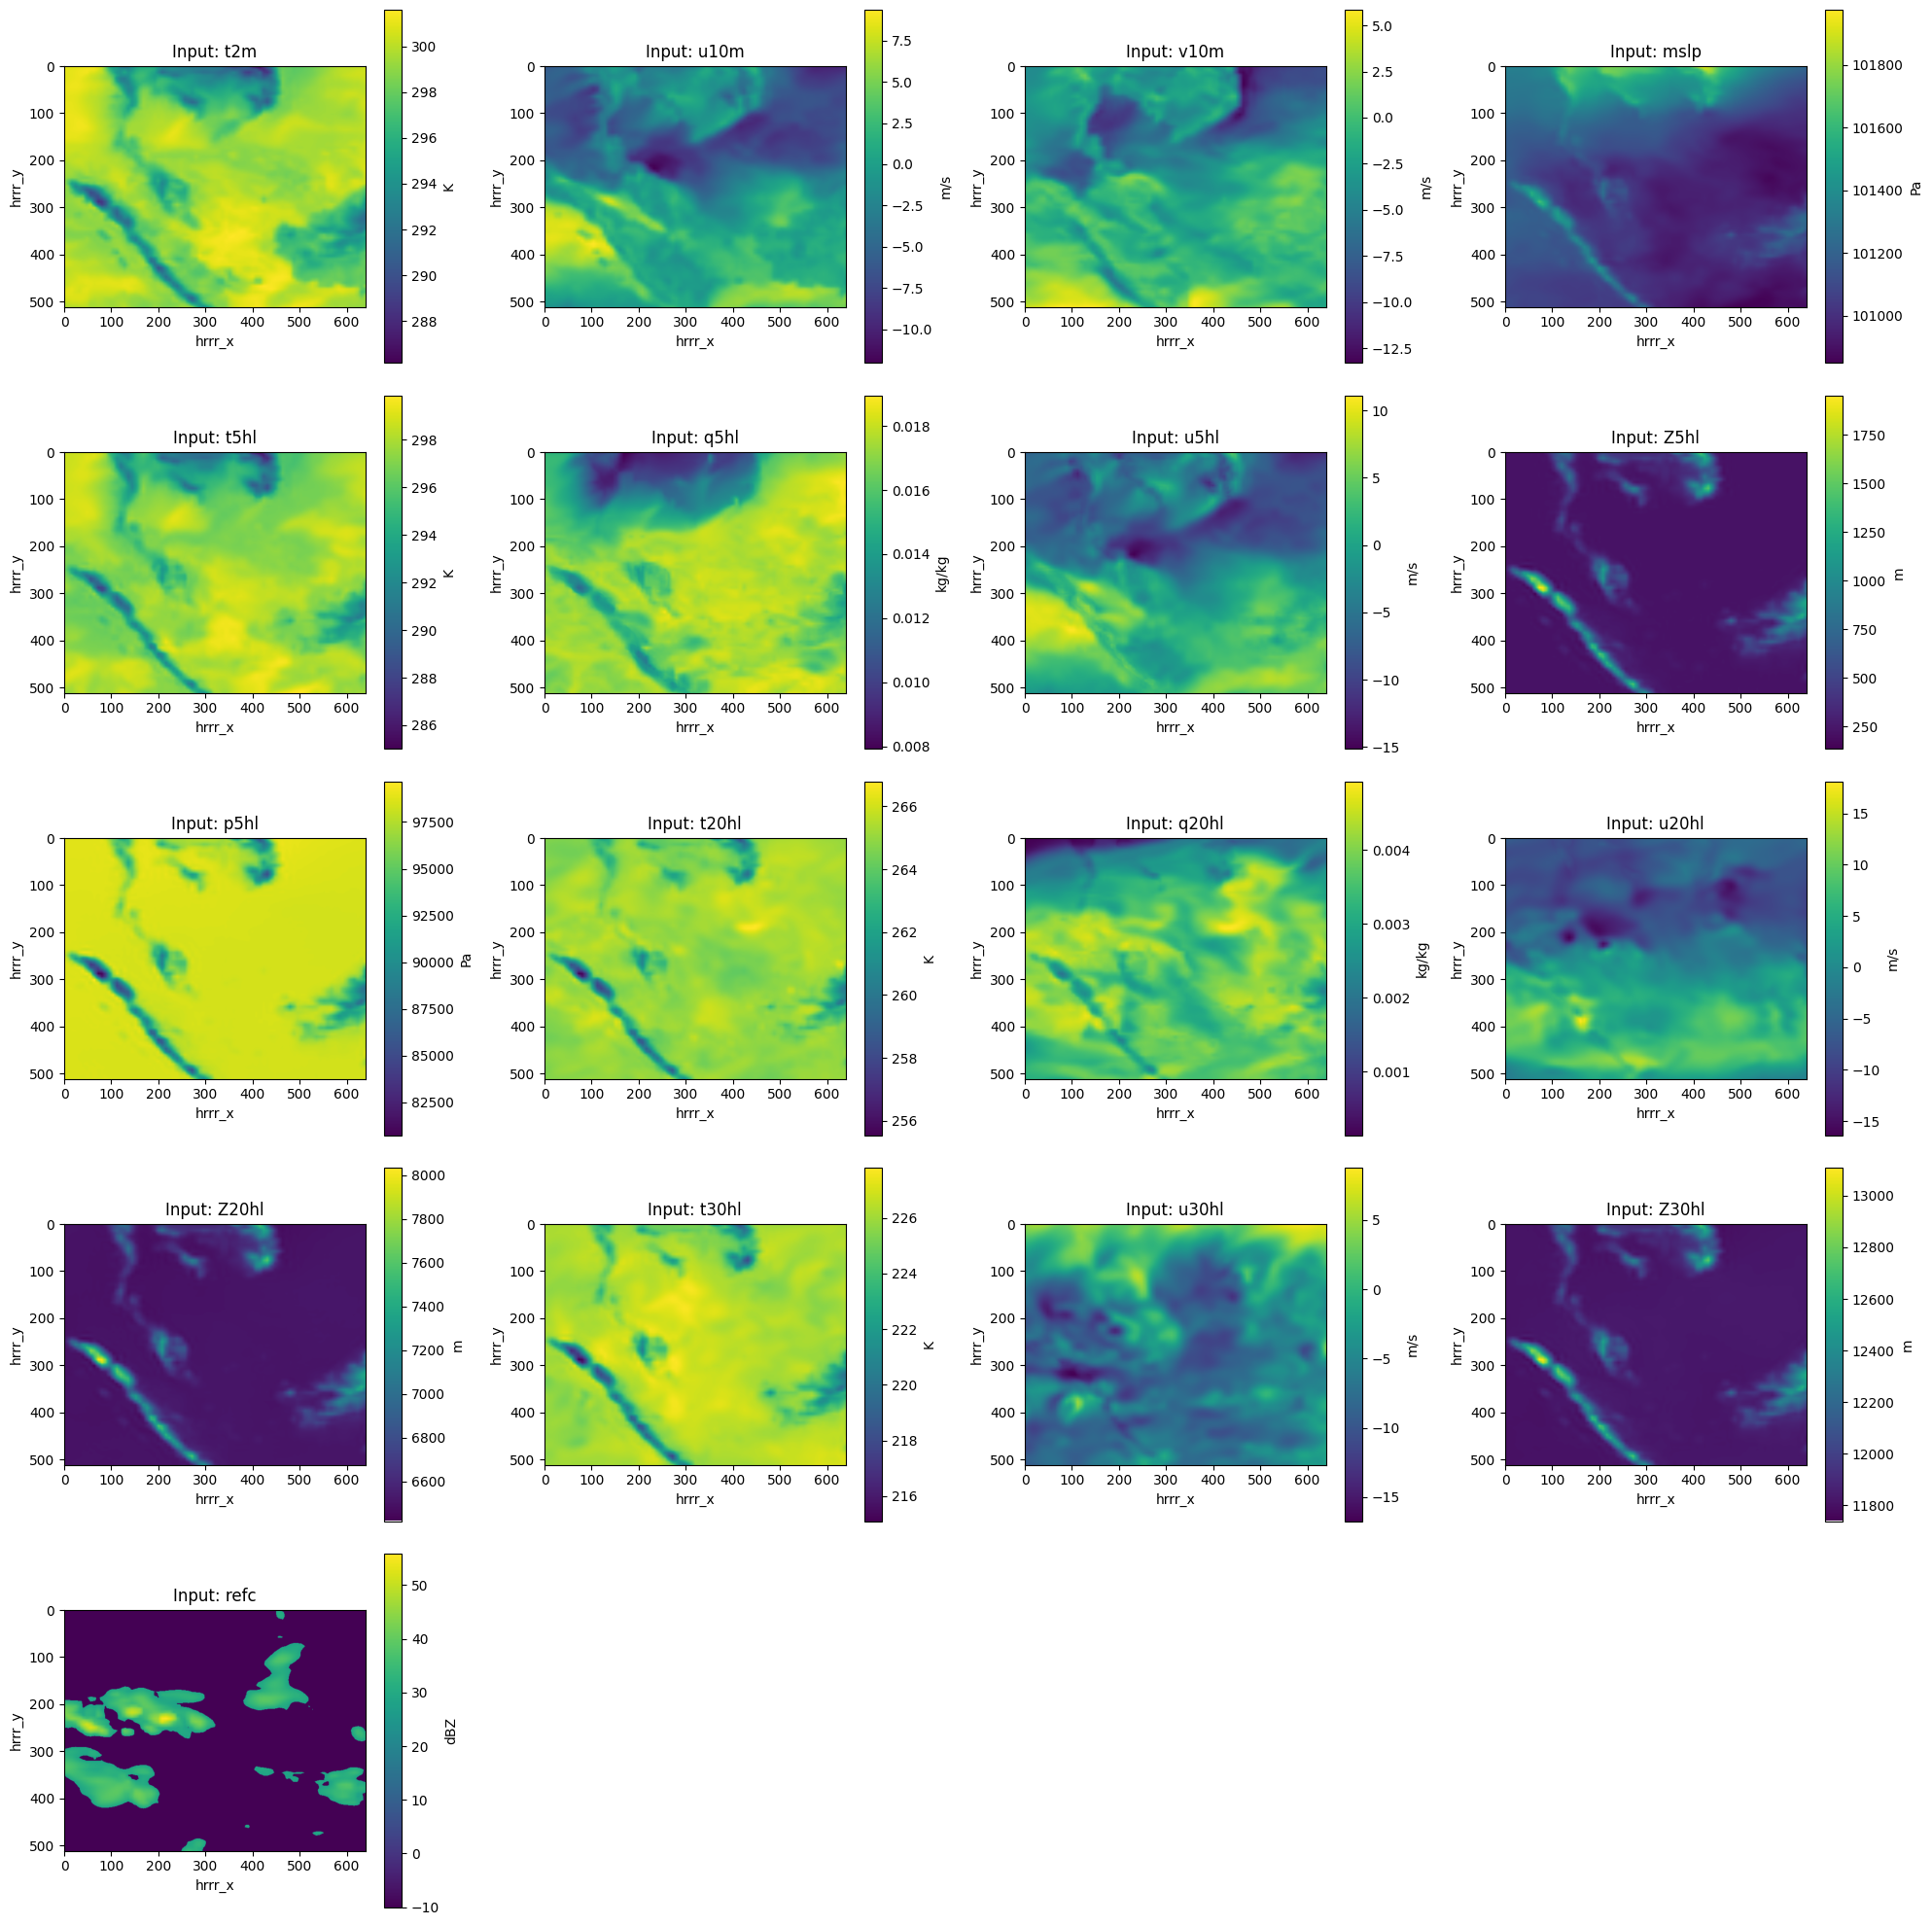

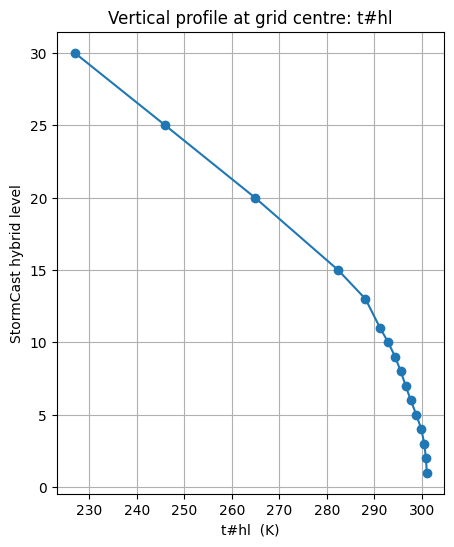

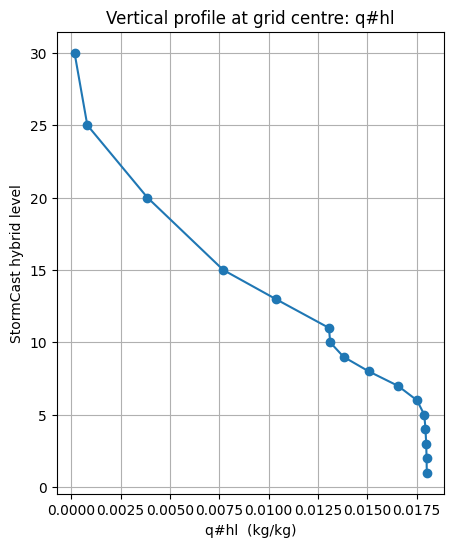

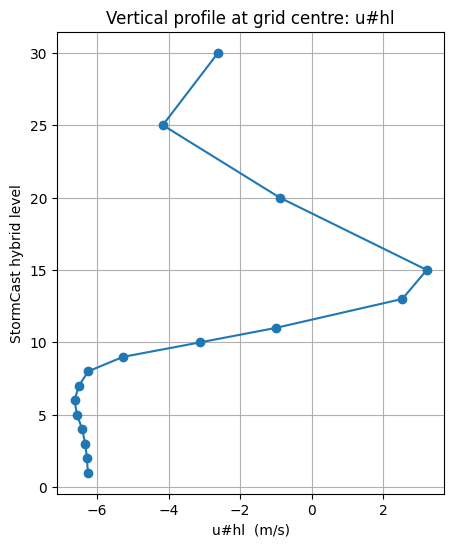

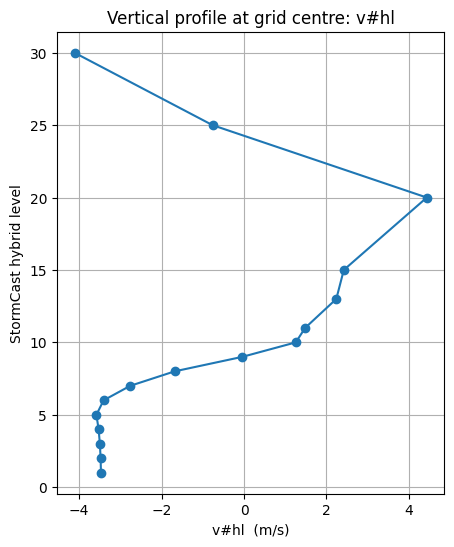

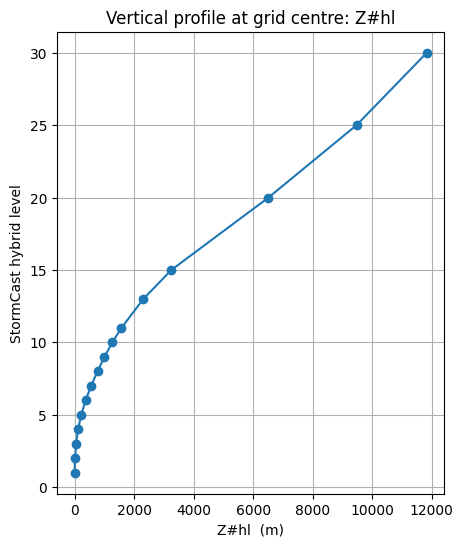

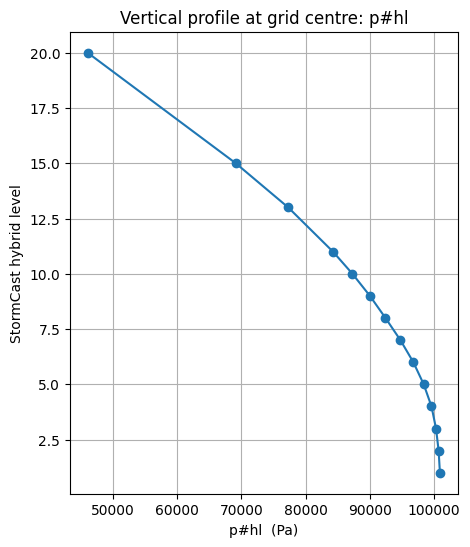

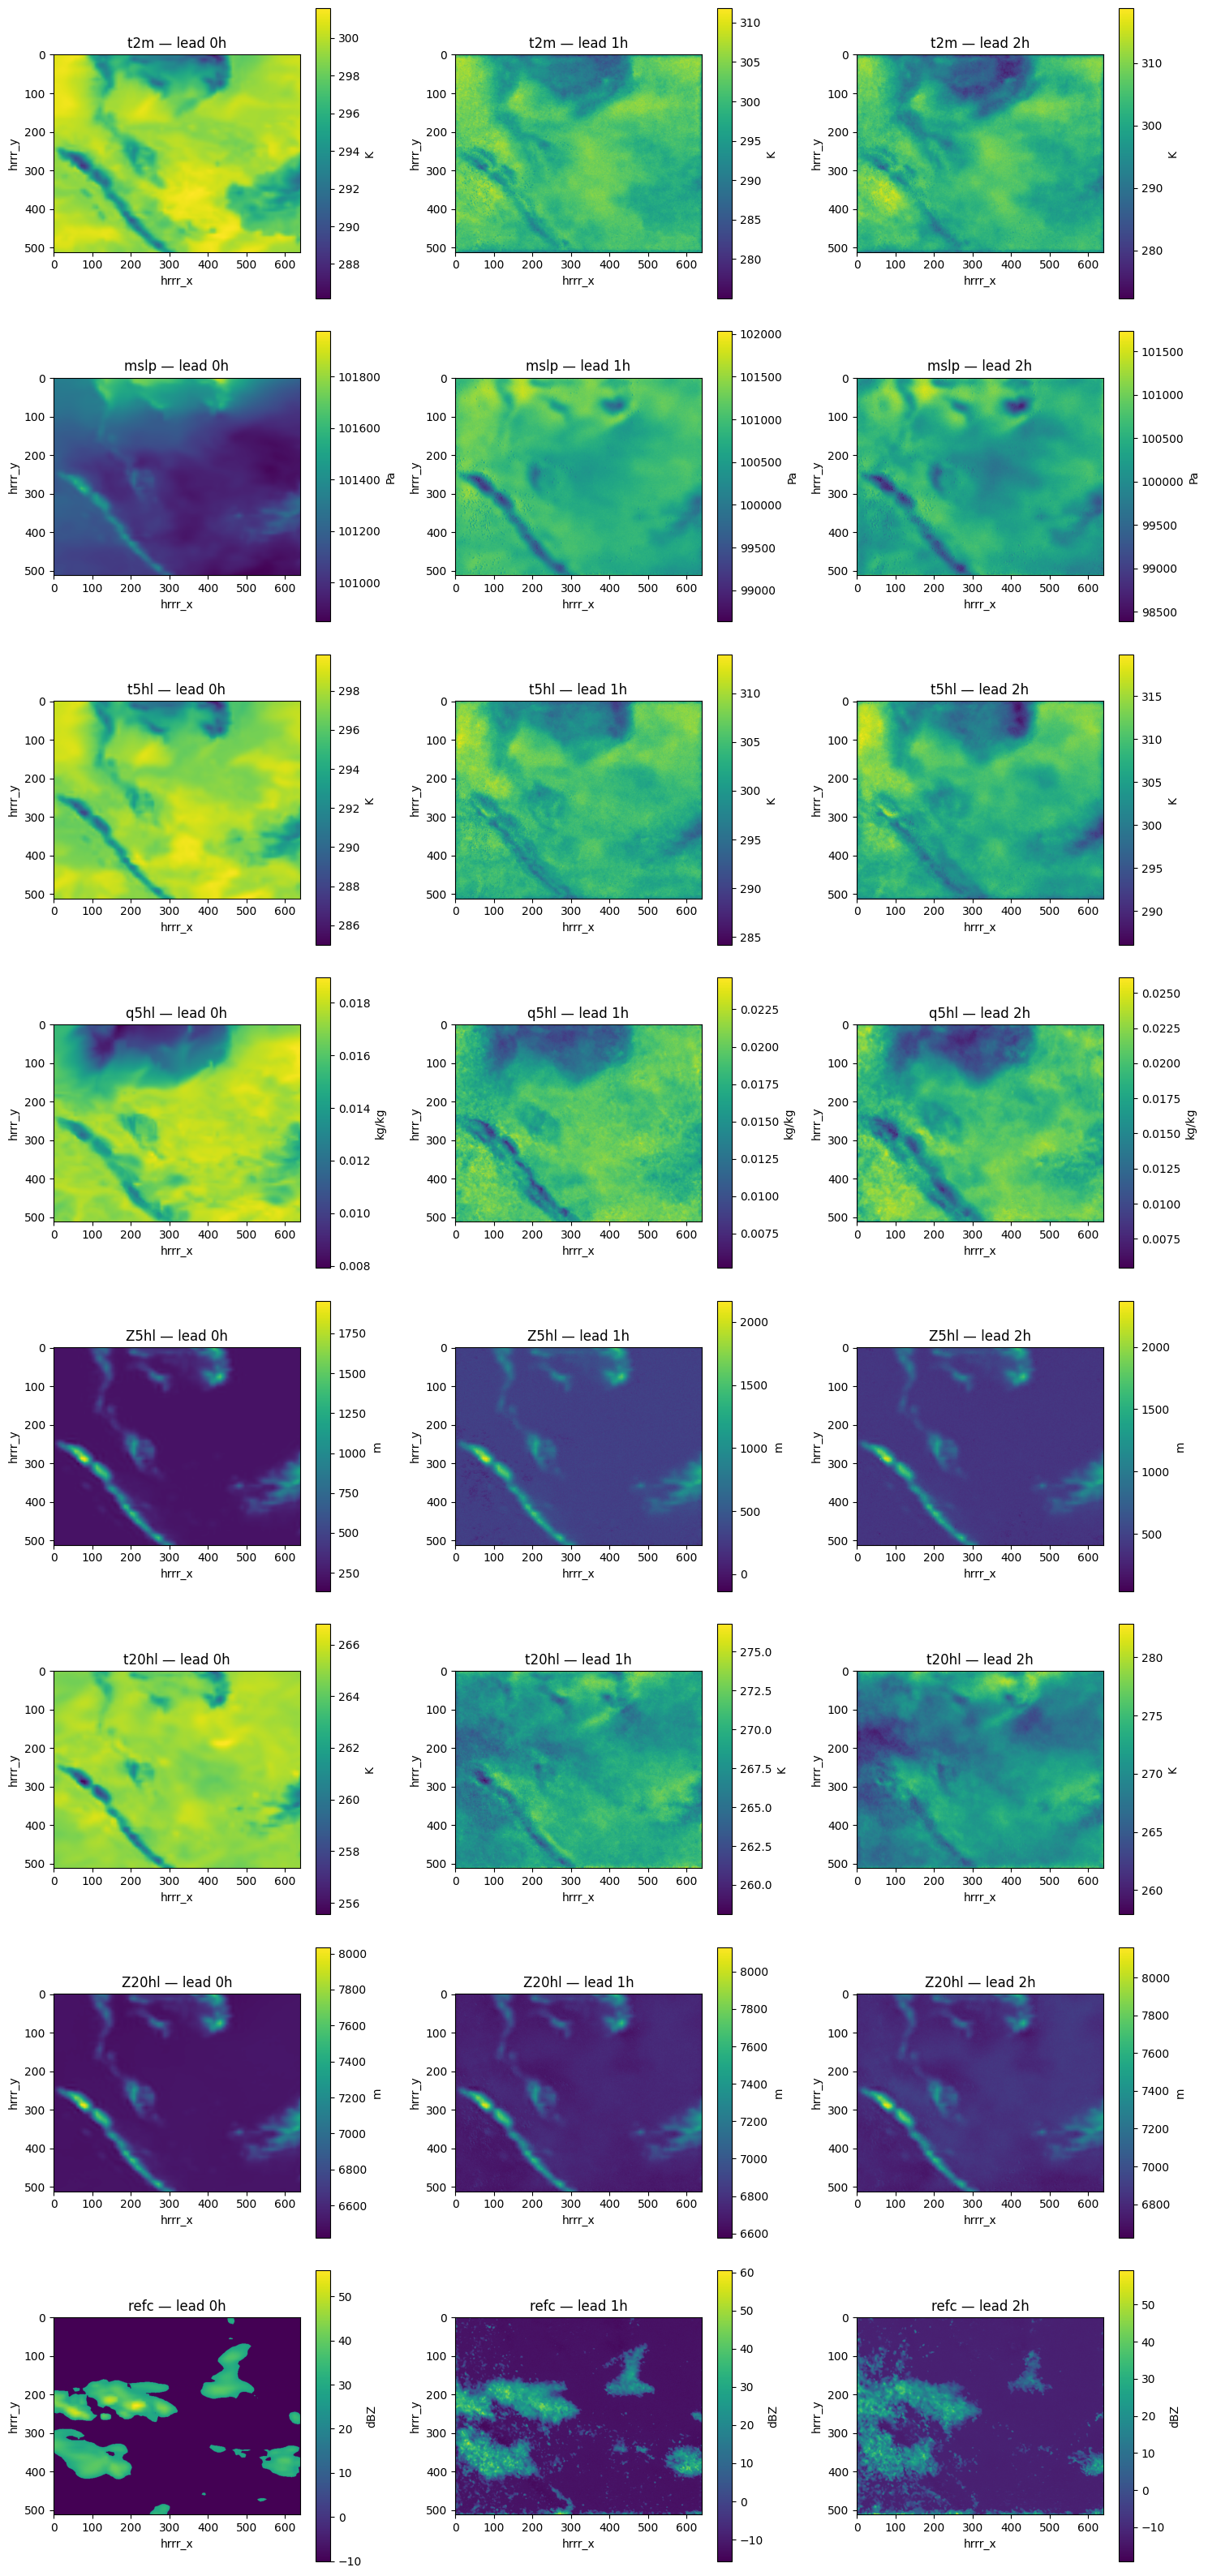

In [5]:
# ── 8. Plots ──────────────────────────────────────────────────────────────────

# Input fields
INPUT_VARS = [
    "t2m", "u10m", "v10m", "mslp",
    "t5hl", "q5hl", "u5hl", "Z5hl", "p5hl",
    "t20hl", "q20hl", "u20hl", "Z20hl",
    "t30hl", "u30hl", "Z30hl", "refc",
]

ut.plot_fields(
    {
        v: data.sel(variable=v).isel(time=0).values
        for v in INPUT_VARS
    },
    title_prefix="Input: ",
)

ut.plot_vertical_profile(data)

# Output fields
ds_out = xr.open_zarr(PATH_OUTPUT)

OUTPUT_VARS = ["t2m", "mslp", "t5hl", "q5hl", "Z5hl", "t20hl", "Z20hl", "refc"]

n_leads = ds_out.sizes["lead_time"]
n_vars = len(OUTPUT_VARS)

fig, axes = plt.subplots(
    n_vars,
    n_leads,
    figsize=(5 * n_leads, 4 * n_vars),
    squeeze=False,
)

for row, var in enumerate(OUTPUT_VARS):
    for col in range(n_leads):
        field = ds_out[var].isel(time=0, lead_time=col).values

        im = axes[row, col].imshow(field, origin="upper")
        axes[row, col].set_title(f"{var} — lead {col}h")
        axes[row, col].set_xlabel("hrrr_x")
        axes[row, col].set_ylabel("hrrr_y")

        plt.colorbar(im, ax=axes[row, col], label=ut.infer_unit(var))

plt.tight_layout()
plt.show()